In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

In [56]:
df=pd.read_csv("..\\data\\Crop_recommendation.csv")
df.sample(10)

,N,P,K,temperature,humidity,ph,rainfall,label
1497,106,21,52,28.895786,94.789930,6.286515,23.036250,muskmelon
530,22,44,24,24.309351,56.329383,6.030447,58.995363,mothbeans
38,60,43,44,21.019447,82.952217,7.416245,298.401847,rice
1667,36,29,13,20.681852,90.915105,7.829507,109.751393,orange
696,4,44,19,27.956397,83.527060,6.921994,43.257268,mungbean
722,52,71,16,27.742748,68.539971,7.075886,71.786153,blackgram
1520,35,128,205,21.072734,93.565860,6.041054,107.873701,apple
794,29,70,15,30.334997,63.547189,6.872594,74.166991,blackgram
1997,110,39,18,24.547953,75.397527,7.766260,63.880799,cotton
1551,20,139,202,23.502014,92.210840,5.669991,107.986895,apple


In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [58]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [59]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
N,2200.0,50.551818,36.917334,0.000000,21.000000,37.000000,84.250000,140.000000
P,2200.0,53.362727,32.985883,5.000000,28.000000,51.000000,68.000000,145.000000
K,2200.0,48.149091,50.647931,5.000000,20.000000,32.000000,49.000000,205.000000
temperature,2200.0,25.616244,5.063749,8.825675,22.769375,25.598693,28.561654,43.675493
humidity,2200.0,71.481779,22.263812,14.258040,60.261953,80.473146,89.948771,99.981876
ph,2200.0,6.469480,0.773938,3.504752,5.971693,6.425045,6.923643,9.935091
rainfall,2200.0,103.463655,54.958389,20.211267,64.551686,94.867624,124.267508,298.560117


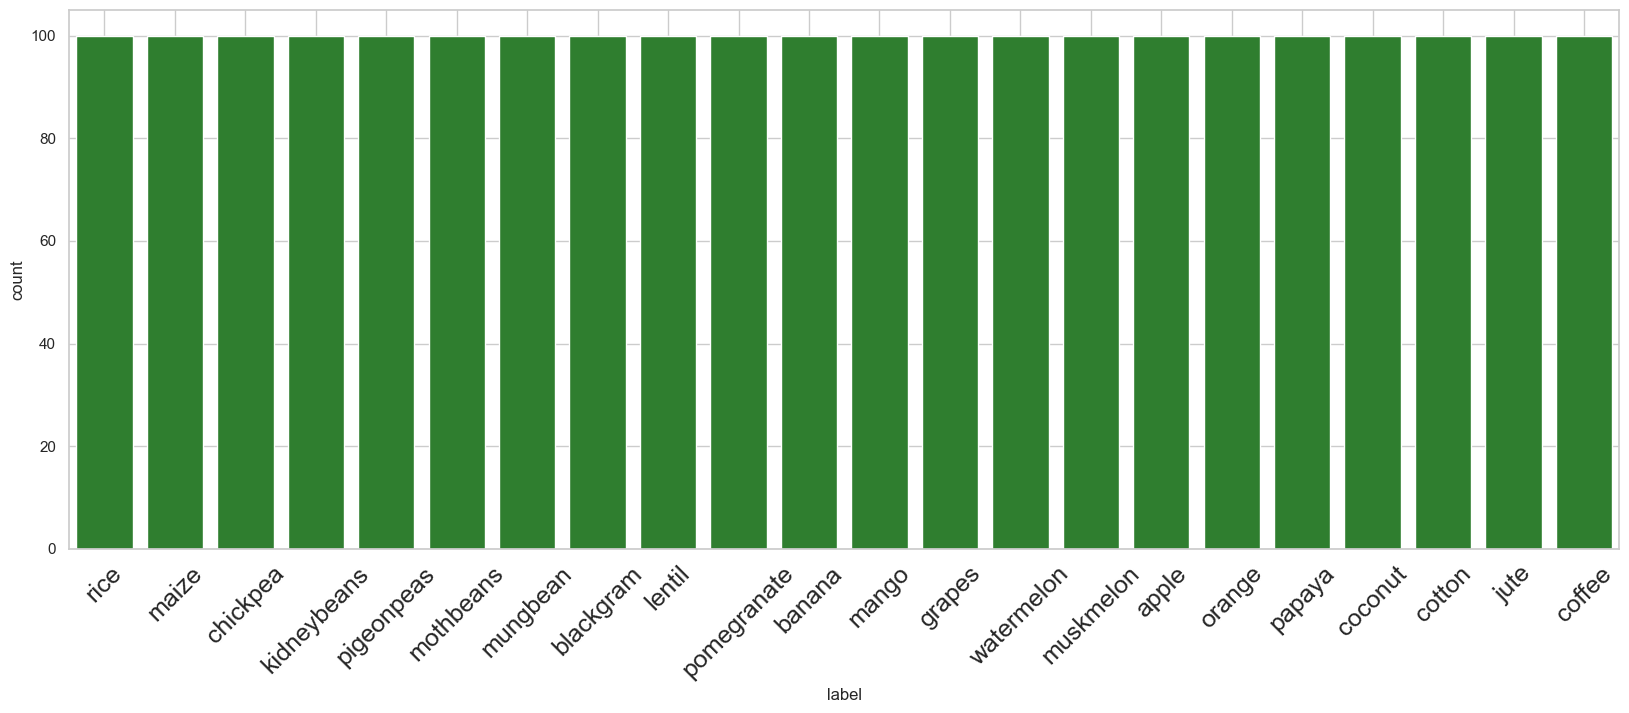

In [60]:
import seaborn as sns
plt.figure(figsize=(20,7))
sns.countplot(x='label', data=df, color='forestgreen')
plt.grid(True)
plt.xticks(rotation=45,fontsize=18)
plt.show()

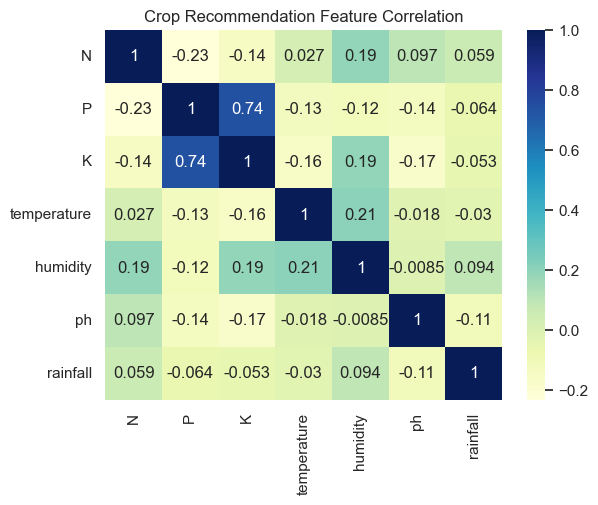

In [61]:
sns.heatmap(df.drop('label', axis=1).corr(),annot=True,cmap='YlGnBu')
plt.title('Crop Recommendation Feature Correlation')
plt.show()

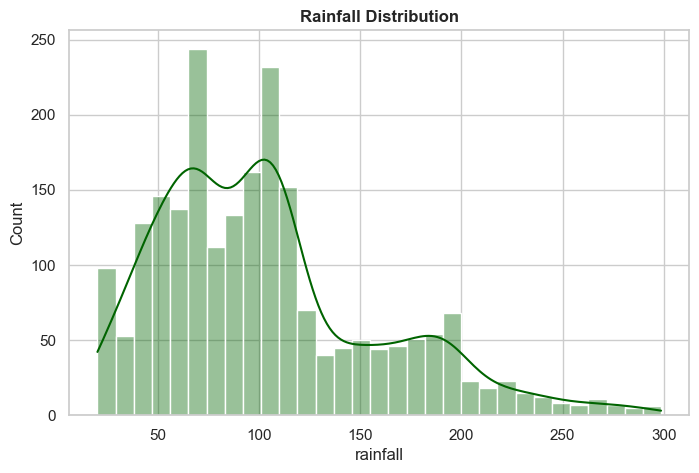

In [63]:
plt.figure(figsize=(8,5))
sns.histplot(df['rainfall'],kde=True,color='darkgreen', alpha=0.4)
plt.title('Rainfall Distribution', fontweight='bold')
plt.show()

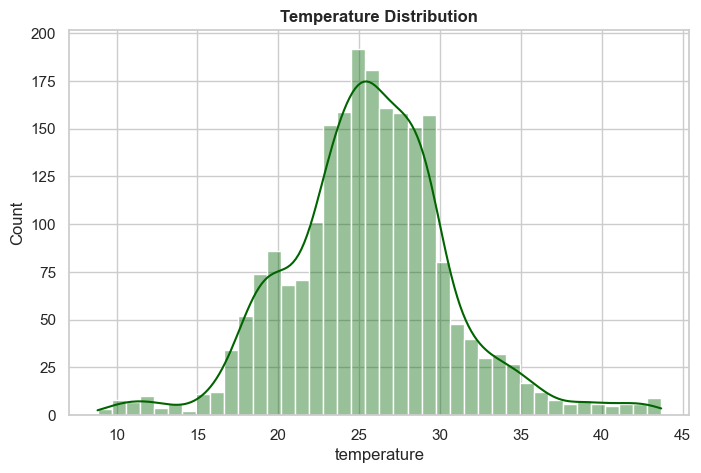

In [65]:
plt.figure(figsize=(8,5))
sns.histplot(df['temperature'],kde=True,color='darkgreen', alpha=0.4)
plt.title('Temperature Distribution', fontweight='bold')
plt.show()

In [ ]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [ ]:
X = df.iloc[:,:-1]
y=df.iloc[:,-1]
X.head()

,N,P,K,temperature,humidity,ph,rainfall
0,90,42,43,20.879744,82.002744,6.502985,202.935536
1,85,58,41,21.770462,80.319644,7.038096,226.655537
2,60,55,44,23.004459,82.320763,7.840207,263.964248
3,74,35,40,26.491096,80.158363,6.980401,242.864034
4,78,42,42,20.130175,81.604873,7.628473,262.717340


In [ ]:
y.head(10)

0    rice
1    rice
2    rice
3    rice
4    rice
5    rice
6    rice
7    rice
8    rice
9    rice
Name: label, dtype: object

In [ ]:
X.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='object')

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

df['Crop_Encoded']=y_encoded
df.sample(10)

,N,P,K,temperature,humidity,ph,rainfall,label,Crop_Encoded
288,53,65,76,20.191378,16.419983,8.719961,77.337954,chickpea,3
1257,19,120,195,18.739322,81.121092,5.931538,73.558080,grapes,7
1534,24,142,202,22.537797,91.481358,5.710820,101.847477,apple,0
20,89,45,36,21.325042,80.474764,6.442475,185.497473,rice,20
742,28,68,19,34.638810,61.385979,7.699507,72.431691,blackgram,2
1289,38,120,197,17.543830,82.947033,6.323723,73.770637,grapes,7
1490,80,18,51,28.053807,91.817588,6.706053,20.765821,muskmelon,15
1168,33,31,34,31.329956,50.222876,5.421265,89.782162,mango,12
42,83,60,36,25.597049,80.145093,6.903986,200.834898,rice,20
483,39,57,19,29.323796,45.932484,6.421748,165.411337,pigeonpeas,18


In [ ]:
df['label'].nunique()

22

In [ ]:
joblib.dump(le,'..\\models\\label_encoder.pkl')

['..\\models\\label_encoder.pkl']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y_encoded,test_size=0.2)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
y_pred_dt = dt.predict(X_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred_rf = rf.predict(X_test)

In [68]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
acc_dt = accuracy_score(y_test, y_pred_dt)
prc_dt=precision_score(y_test, y_pred_dt,average='weighted')
rec_dt=recall_score(y_test, y_pred_dt,average='weighted')
f1_dt = f1_score(y_test,y_pred_dt,average='weighted')
mis_dt=np.sum(y_test!=y_pred_dt)

acc_rf = accuracy_score(y_test, y_pred_rf)
prc_rf=precision_score(y_test, y_pred_rf,average='weighted')
rec_rf=recall_score(y_test, y_pred_rf,average='weighted')
f1_rf = f1_score(y_test,y_pred_rf,average='weighted')
mis_rf=np.sum(y_test!=y_pred_rf)

In [69]:
results = pd.DataFrame({
    'Model':['Decision Tree','Random Forest'],
    'Accuracy':[acc_dt,acc_rf],
    'Precision':[prc_dt,prc_rf],
    'Recall': [rec_dt,rec_rf],
    'F1 Score':[f1_dt,f1_rf],
    'Misclassifications':[mis_dt,mis_rf]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,Misclassifications
0,Decision Tree,0.997727,0.997854,0.997727,0.997733,1
1,Random Forest,1.000000,1.000000,1.000000,1.000000,0


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_rf,target_names=le.classes_))

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        15
      banana       1.00      1.00      1.00        22
   blackgram       1.00      1.00      1.00        17
    chickpea       1.00      1.00      1.00        21
     coconut       1.00      1.00      1.00        23
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        16
      grapes       1.00      1.00      1.00        23
        jute       1.00      1.00      1.00        15
 kidneybeans       1.00      1.00      1.00        22
      lentil       1.00      1.00      1.00        20
       maize       1.00      1.00      1.00        26
       mango       1.00      1.00      1.00        23
   mothbeans       1.00      1.00      1.00        22
    mungbean       1.00      1.00      1.00        18
   muskmelon       1.00      1.00      1.00        19
      orange       1.00      1.00      1.00        21
      papaya       1.00    

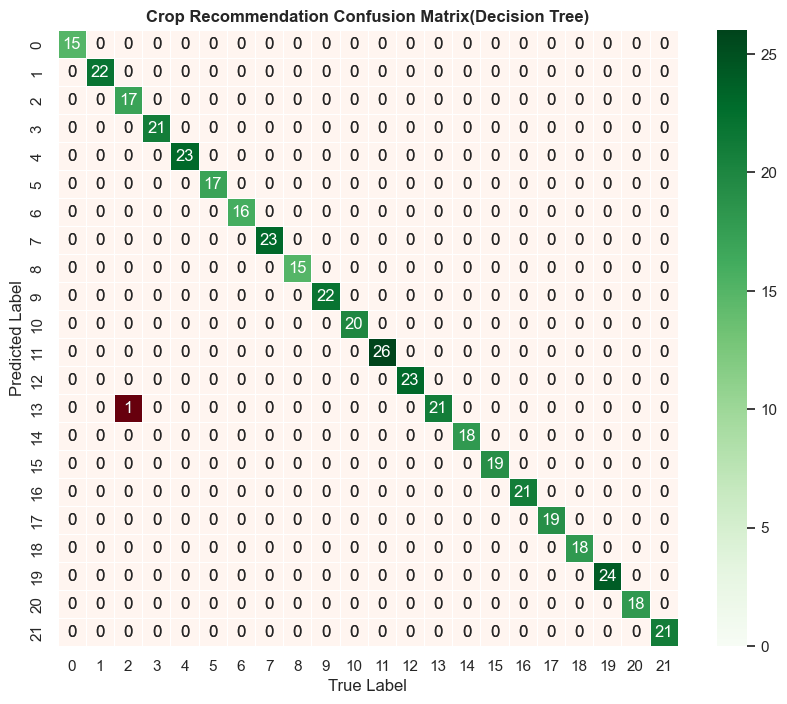

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(y_test,y_pred_dt)
sns.set_theme(style="whitegrid", palette="GnBu")
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt='d',cmap='Greens')
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds',mask=np.eye(cm.shape[0], dtype=bool),cbar=False,linewidths=0.5,linecolor='white')
plt.title('Crop Recommendation Confusion Matrix(Decision Tree)',fontweight='bold',fontsize=12)
plt.xlabel('True Label')
plt.ylabel('Predicted Label')
plt.show()

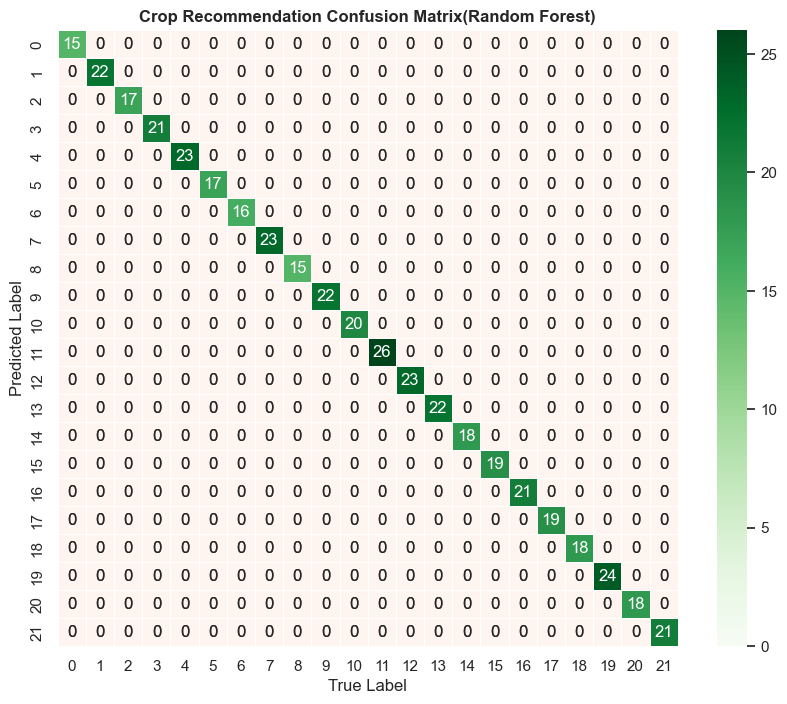

In [ ]:

cm = confusion_matrix(y_test,y_pred_rf)
sns.set_theme(style="whitegrid", palette="GnBu")
plt.figure(figsize=(10,8))

sns.heatmap(cm,annot=True,fmt='d',cmap='Greens')
sns.heatmap(cm,annot=True,fmt='d',cmap='Reds',mask=np.eye(cm.shape[0], dtype=bool),cbar=False,linewidths=0.5,linecolor='white')
plt.title('Crop Recommendation Confusion Matrix(Random Forest)',fontweight='bold',fontsize=12)
plt.xlabel('True Label')
plt.ylabel('Predicted Label')
plt.show()

In [ ]:
importance = pd.DataFrame({'Feature':X.columns,'Importance':rf.feature_importances_})
importance.sort_values(by='Importance',ascending=False,inplace=True)
importance

,Feature,Importance
6,rainfall,0.232518
4,humidity,0.210093
2,K,0.174600
1,P,0.144526
0,N,0.104250
3,temperature,0.076721
5,ph,0.057292


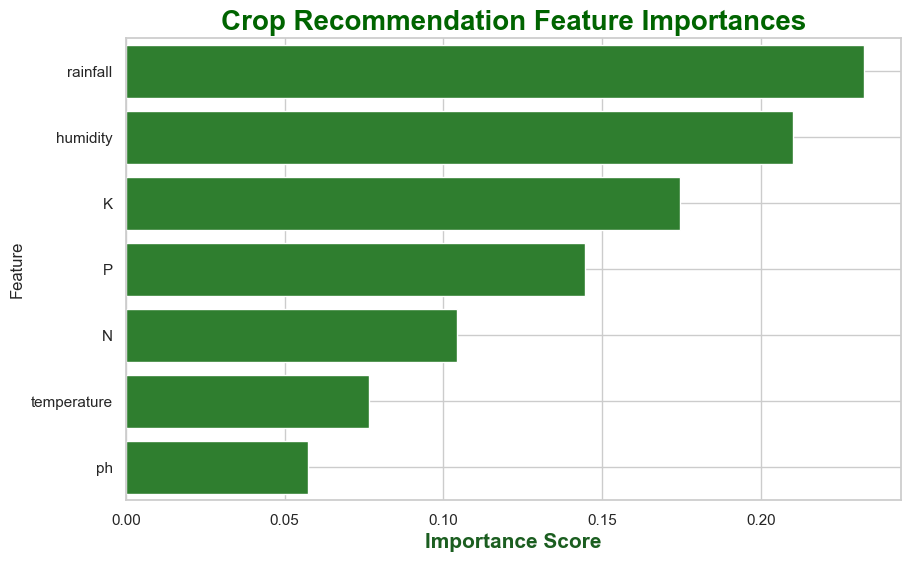

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance,x=importance['Importance'],y=importance['Feature'],color='forestgreen')
plt.title('Crop Recommendation Feature Importances',fontsize=20,fontweight='bold',color='darkgreen')
plt.xlabel('Importance Score',fontsize=15,fontweight='bold',color='#1B5E20')
plt.grid(True)

In [ ]:
new_data = pd.DataFrame({
    'N':[90],
    'P':[42],
    'K':[43],
    'temperature':[22.5],
    'humidity':[80],
    'ph':[6.5],
    'rainfall':[200]
})

In [ ]:
pred = rf.predict(new_data)

crop_name = le.inverse_transform(pred)

print(crop_name)

['rice']


In [ ]:
joblib.dump(rf, '../models/crop_recommendation_RFC.pkl')

['../models/crop_recommendation_RFC.pkl']

In [ ]:
df.sample()

,N,P,K,temperature,humidity,ph,rainfall,label,Crop_Encoded
1099,117,81,53,29.507046,78.205856,5.507642,98.125658,banana,1
